*Your Name*

*Collaborator's Names*

# Memory and Performance

The lecture covered how data flows through a computer in order to execute our code. Most importantly, we introduced the memory hierarchy, the fetch-execute-store cycle, and the basic idea of how data is laid out in memory (also called **data locality**)

In this workbook, you'll put these ideas together to learn:
* why NumPy arrays are faster than lists for particular kinds of applications
* why some methods of creating lists are faster than others

Future lessons will build on this understanding of data locality and how it impacts performance, as well as the ability to time code execution.

---
## Diagraming Memory Flow

In the last part of lecture, we introduced **cache lines** as well as the implementation underlying **Python lists** and **NumPy arrays**. 

The structure of NumPy arrays let's them take advantage of cache lines due to high data locality.

For simplicity in the following exercises, **you only need to consider RAM and L1 cache.** We'll use these to represent the whole memory hierarchy (e.g. ingore L2 and L3 cahces). The CPU's registers are so small it is very unlikely that they see any data re-use.

We will also assume that **a cache line can fit 8 floating point numbers.**

### NumPy Arrays

Imagine we have created an array with the following command:

```python
a = np.ones(100)
```

This array has size 100, defaults to holding floating point numbers, and every value is set to `1.0`. Remember that arrays store their data in a block of contiguous memory address. It might be helpful to image the array like table in memory:

| `a[0]` | `a[1]` | `a[2]` | `a[3]` | ... |
|--------|--------|--------|--------|-----|
| `1.0`  | `1.0`  | `1.0`  | `1.0`  | ... |


Some time after we created the array, we need to access it for calculations. associated with this time, the array is only present in RAM. We loop through the array as follows:

```python
for i in range(a.size):
    a[i] *= 5
```


---
#### Exercises

1. Which entry in array `a` does the CPU request first? Where is it **first** able to find this value, RAM or L1 cache?

The CPU first requests entry 0, which is stored in RAM

2. After the CPU requests `a[0]`, what's the highest index of `a` available in L1 cache?

Index 7

3. When `i=3`, where is the CPU **first** able to find this value? (i.e., on what level does it stop looking through the memory hierarchy)

L1 cache

4. Later, when `i=8`, where is the CPU **first** able to find this value? What action does this trigger?

RAM; it triggers the transfer of a cache line to L1 cache

---
### Python Lists

Now imagine we have created a list that is similar to `a`; that is, it hold 100 floating point numbers, all of which are `1.0`. We'll do so with a [list comprehension](https://www.w3schools.com/python/python_lists_comprehension.asp). We'll explore this technique for creating lists later in this workbook.

```python
l = [1.0 for i in range(100)]
```

Like arrays, lists are also stored as contiguous blocks of memory addresses; *however* each of these blocks is a *pointer*. The actual data we are using a list to store is kept at some other memory address that is referenced by the pointer.

Thinking in terms of a table, the list looks like this:

| `l[0]` | `l[1]` | `l[2]` | `l[3]` | ... |
|--------|--------|--------|--------|-----|
| `0x3e8` | `0x3e9` | `0x578` | `0x7d0`  | ... |

Here, we're using **hexadecimal numbers** (i.e., numbers written in base 16) to refer to memory addresses. These numbers start with `0x` and use the letters `a` through `f` to represent digits 10 through 15. They are commonly used to represent memory addresses.

The pointers above may or may not point to contiguous blocks of memory. For instance, `l[0]` and `l[1]` both reference coniguous addresses:

| `0x3e8` | `0x3e9` |
|---------|---------|
| `1.0`   | `1.0`   |

Other entries, such as `l[2]`, are not contiguous with any other data in the list.

In order to access the data associated with `l[0]`, we must first fetch the pointer associated with `l[0]`, and then the data stored at the address indicated by the pointer.

Some time after we created the list, we need to access it for calculations. At this time, the list is only present in RAM. We loop through the list as follows:

```python
for i in range(a.size):
    l[i] *= 5
```

Be aware that cache lines are used **any** time we need to move data. The computer is *hoping* that data in the cache line will be used soon in the future, but this does not have to be true.

---
#### Exercises

1. When the CPU tries to access the data associated with `l[0]`, how many cache lines are needed to transfer this data out of RAM? Why are these chache lines needed?

Two cache lines are needed because the pointer and its reference are at different locations in memory.

2. When the CPU tries to access the data associated with `l[1]`, how many cache lines are needed to transfer this data out of RAM? What data (if any) is already present in the L1 cache?

No additional cache lines should be needed as both the pointer at l[1] and its reference should have already been copied into L1 when l[0] was accessed

3. Next, when the CPU tries to access the data associated with `l[2]`, how many cache lines are needed to transfer this data out of RAM? What data (if any) is already present in the L1 cache?

One cache line is needed to fetch the l[2] pointer's reference. The pointer for l[2] is already in L1 cache.

---
## Vectorization 

Sometimes, a CPU can apply the same instruction to multiple pieces of data at the same time in a processes called **vectorization.** Consider our NumPy example from before:

```python
a = np.ones(100)
for i in range(a.size):
    a[i] * 5
```

In its current form, the CPU can take advantage of cache lines, but it *cannot* employ vectorization. Simply put, we are relying too much on "pure" Python for vectorization to take place. Python's way of handling instructions does not make it clear to the CPU that vectorization is possible.

That said, *NumPy* supports vectorization due to how its implemented (in C).
We can rewrite our `for` loop to take advantage of this:

```python
a = np.ones(100)
a * 5
```

---
### Exercises

1. Time the `for` loop displayed above. Don't include array creation or module import in your timing measurement!

In [7]:
import numpy as np
a = np.ones(100)

In [8]:
%%timeit
for i in range(a.size):
    a[i] * 5

15.6 μs ± 103 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


2. Time the vectorized NumPy statement displayed above. How many times faster is this version?

In [9]:
a = np.ones(100)
%timeit a * 5

1.47 μs ± 6.62 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


About 10 times faster

3. Time the following purely "Pythonic" code to establish a baseline to compare performance improvements against. Exclude the import statement from your timing.

```python
import math

b = []
for i in range(500):
    b.append(i * math.sin(i))
```

In [10]:
import math

In [11]:
%%timeit
b = []
for i in range(500):
    b.append(i * math.sin(i))

57.6 μs ± 394 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


4. Rewrite the above code to be more "NumPythonic" in order to take advantage of vectorization. The NumPy [array creation](https://numpy.org/doc/1.25/reference/routines.array-creation.html#numerical-ranges) and [math](https://numpy.org/doc/1.25/reference/routines.math.html) documentation pages are good references. Make sure to test the results of your refactor!

In [12]:
b = []
for i in range(500):
    b.append(i * math.sin(i))
print(b[:10])

[0.0, 0.8414709848078965, 1.8185948536513634, 0.4233600241796016, -3.027209981231713, -4.794621373315692, -1.6764929891935552, 4.598906191031523, 7.914865972987054, 3.7090663671758093]


In [13]:
temp = np.arange(500)
b = temp * np.sin(temp)
print(b[:10])

[ 0.          0.84147098  1.81859485  0.42336002 -3.02720998 -4.79462137
 -1.67649299  4.59890619  7.91486597  3.70906637]


5. Time the result of your refactor. What factor of speedup did you achieve? (i.e., what is the ratio between the old time and the new time?)

In [14]:
%%timeit
temp = np.arange(500)
b = temp * np.sin(temp)

10.7 μs ± 29.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


11 times speedup!

6. Using what you've learned about caches and cache lines, explain why vectorization is possible and why it lets code run faster.

The values needed for the next iteration of the loop are already present in L1 cache so they can be pulled into the registers for a SIMD operation

---
## A Final Comparison

In this workbook, we've explored different ways to work with lists and NumPy arrays. We've also learned so details about how these objects work under the hood, and how their implementations can bring benefits and drawbacks.

Now, we will directly compare these methods against each other. You will implement a vector norm (also called the "dot product") in several different ways:

1. Looping over a list
3. Looping over a NumPy array
4. Using `np.sum()`
5. Using `np.dot()`

For example, for a vector with 1 million elements, item #5 would be implemented as
```python
vec = np.arange(1e6)
norm = np.sum(vec * vec)
```

You are encouraged to look up the documentation for any functions you are unfamiliar with.


---
### Exercises
1. Time how long it takes to calculate `norm` with each implementation. Make sure you test the same vector each time.


In [15]:
import numpy as np
vec_lst = list(range(1000000))
vec_arr = np.arange(1e6)

In [16]:
%%timeit
norm = 0
for v in vec_lst:
    norm += v * v

56.5 ms ± 2.68 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [18]:
%%timeit
norm = 0
for v in vec_arr:
    norm += v * v

166 ms ± 6.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [21]:
%timeit np.sum(vec_arr * vec_arr)

685 μs ± 16.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [22]:
%timeit np.dot(vec_arr, vec_arr)

14.5 ms ± 4.59 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


From fastest to slowest:
1. np.dot (np.sum?)
2. np.sum (np.dot?)
3. list for
5. numpy for

This is very similar to the book's ranking

2. Using what you've learned this lesson, explain why you think the ranking turned out the way it is. What, if anything, can you not explain?

The NumPy functions are faster because they can be more optimized under the hood.It's interesting that iterating over NumPy arrays is slower than iterating over the list; however, `vec * vec` is still able to take advantage of vectorization.

3. What have you taken away from this comparison?

Specialized functions can give big performance boosts!

---
## Refactoring Lists to NumPy Arrays

The code below simulates a simple 1D diffusion problem. Entries in a list function as cells in a grid,
where each cell's value represents the concentration of a fluid at a point in space. Over time, the concentration in each cell will change as the fluid redistributes. **You will be incrementally refactoring this list-based code to use NumPy.**

A small region near the center of the grid is given a higher concentration than its surroundings:

![Graph of the initial conditions for our sample 1D diffusion problem.](diffusion_ICs.png "Diffusion Initial Conditions")

After 500 iterations (timesteps) with the default parameters, the concentration smooths out:

![Graph of the diffusion problem after 500 timesteps.](diffusion_updated.png "Diffusion After 500 Timesteps")


In [1]:
import numpy as np

In [2]:
def run_simulation(grid_size = 600, 
                   dt = 0.1,
                   num_iterations = 500,
                   diffusion_coeff = 1.0):
    """
    Simulate the diffusion of a fluid in 1D using lists.
    
    grid_size: the number of cells in our grid.
    dt: time change for each iteration
    num_iterations: how many time steps we allow the fluid to diffuse.
    diffusion_coeff: diffusivity of the fluid; higher is more diffusive.

    Returns the state of the grid after num_iterations
    """

    # Construct 1D grid
    # Add an additional cell at each end to handle grid boundaries
    # grid[0] and grid[grid_size+1] are these boundary cells
    grid = [0.01] * (grid_size + 2)

    # Set the initial conditions
    # A small region (~10% of total length)
    # near the middle has high concentration
    start_index = int(grid_size * 0.4)
    end_index = int(grid_size * 0.5)
    for i in range(start_index+1, end_index+1):
        grid[i] = 0.02

    # Evolve the grid
    for t in range(num_iterations):

        # create a new grid to store updates
        new_grid = [0.0] * (grid_size + 2)

        # update main grid
        for i in range(1, grid_size+1):
            stencil = grid[i+1] + grid[i-1] - 2*grid[i]
            new_grid[i] = grid[i] + diffusion_coeff * stencil * dt

        # update boundary cells
        new_grid[0] = new_grid[1]
        new_grid[grid_size+1] = new_grid[grid_size]

        # swap new_grid and grid
        grid, new_grid = new_grid, grid

    return grid


---
### Exercises

1. Time `run_simulation` using the `%%timeit` magic command to establish a baseline. Magic commands like this are exclusive to Jupyter notebooks but are very useful. This particular command should be put at the top of the cell, before any lines of Python code.

You can use the default arguments for `run_simulation`.

In [3]:
%timeit run_simulation()

32 ms ± 456 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


2. Defining a new function, convert `grid` and `new_grid` to NumPy arrays (recall the [array creation](https://numpy.org/doc/1.25/reference/routines.array-creation.html#numerical-ranges) routines). Check the results against the figures shown above and time your refactor. Is this version of the code slower or faster? Why do you think that is?

In [4]:
import numpy as np
def run_simulation_array(grid_size = 600, 
                        dt = 0.1,
                        num_iterations = 500,
                        diffusion_coeff = 1.0):
    """
    Simulate the diffusion of a fluid in 1D using lists.
    
    grid_size: the number of cells in our grid.
    dt: time change for each iteration
    num_iterations: how many time steps we allow the fluid to diffuse.
    diffusion_coeff: diffusivity of the fluid; higher is more diffusive.

    Returns the state of the grid after num_iterations
    """

    # Construct 1D grid
    # Add an additional cell at each end to handle grid boundaries
    # grid[0] and grid[grid_size+1] are these boundary cells
    grid = 0.01 * np.ones(grid_size + 2)

    # Set the initial conditions
    # A small region (~10% of total length)
    # near the middle has high concentration
    start_index = int(grid_size * 0.4)
    end_index = int(grid_size * 0.5)
    for i in range(start_index+1, end_index+1):
        grid[i] = 0.02

    # Evolve the grid
    for t in range(num_iterations):

        # create a new grid to store updates
        new_grid = np.zeros(grid_size + 2)

        # update main grid
        for i in range(1, grid_size+1):
            stencil = grid[i+1] + grid[i-1] - 2*grid[i]
            new_grid[i] = grid[i] + diffusion_coeff * stencil * dt

        # update boundary cells
        new_grid[0] = new_grid[1]
        new_grid[grid_size+1] = new_grid[grid_size]

        # swap new_grid and grid
        grid, new_grid = new_grid, grid

    return grid


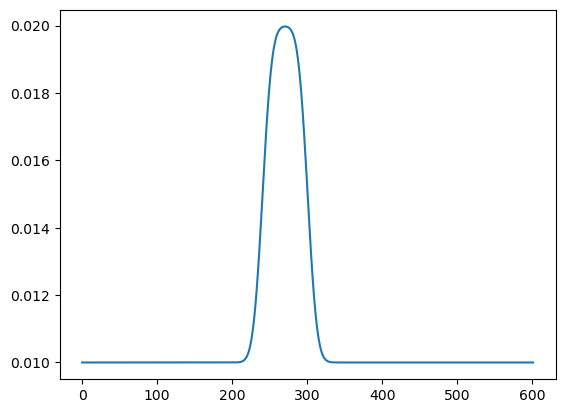

In [5]:
import matplotlib.pyplot as plt
plt.plot(run_simulation_array())

In [6]:
%timeit run_simulation_array()

180 ms ± 1.76 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


It should be slower!

3. Refactor the diffusion code a second time. This time, eliminate the `for` loops by using [array slicing](https://numpy.org/doc/stable/user/absolute_beginners.html#indexing-and-slicing). This will enable us to use vectorization.

Hint: the loop
```python
for i in range(1, grid_size+1):
    grid[i]
```
will become
```python
grid[1:-1]
```
Drawing a diagram may help you, especially when handling the ghost zones!

In [7]:
def run_simulation_slice(grid_size = 600, 
                        dt = 0.1,
                        num_iterations = 500,
                        diffusion_coeff = 1.0):
    """
    Simulate the diffusion of a fluid in 1D using lists.
    
    grid_size: the number of cells in our grid.
    dt: time change for each iteration
    num_iterations: how many time steps we allow the fluid to diffuse.
    diffusion_coeff: diffusivity of the fluid; higher is more diffusive.

    Returns the state of the grid after num_iterations
    """

    # Construct 1D grid
    # Add an additional cell at each end to handle grid boundaries
    # grid[0] and grid[grid_size+1] are these boundary cells
    grid = 0.01 * np.ones(grid_size + 2)

    # Set the initial conditions
    # A small region (~10% of total length)
    # near the middle has high concentration
    start_index = int(grid_size * 0.4)
    end_index = int(grid_size * 0.5)
    grid[start_index+1:end_index+1] = 0.02

    # Evolve the grid
    for t in range(num_iterations):

        # create a new grid to store updates
        new_grid = np.zeros(grid_size + 2)

        # update main grid
        stencil = grid[2:] + grid[:-2] - 2*grid[1:-1]
        new_grid[1:-1] = grid[1:-1] + diffusion_coeff * stencil * dt

        # update boundary cells
        new_grid[0] = new_grid[1]
        new_grid[grid_size+1] = new_grid[grid_size]

        # copy new_grid to grid
        grid, new_grid = new_grid, grid

    return grid


4. Time the slice-based code for 500 timesteps. How does the speed of this change compare to both our previous versions? Is this what you expect?

In [8]:
%timeit run_simulation_slice()

3.76 ms ± 29.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


This is now the fastest version. Switching to NumPy initially imposed a penalty but using slices allowed for vectorization, which should enable a huge speedup.

5. There is one last easy refactor we can do. We have been able to reduce the time spent on some of the code's lines thanks to vectorization. Another strategy is simply to reduce the number of times a line is executed! Which line can benefit from this kind of optimization without breaking the algorithm?

Line 32, where we create `new_grid`, can be moved outside the loop without breaking the algorithm.

6. Refactor the code a final time to implement the optimization identified above. Compared to the *original* version, what is the final factor of speed-up achieved?

In [9]:
def run_simulation_final(grid_size = 600, 
                        dt = 0.1,
                        num_iterations = 500,
                        diffusion_coeff = 1.0):
    """
    Simulate the diffusion of a fluid in 1D using lists.
    
    grid_size: the number of cells in our grid.
    dt: time change for each iteration
    num_iterations: how many time steps we allow the fluid to diffuse.
    diffusion_coeff: diffusivity of the fluid; higher is more diffusive.

    Returns the state of the grid after num_iterations
    """

    # Construct 1D grid
    # Add an additional cell at each end to handle grid boundaries
    # grid[0] and grid[grid_size+1] are these boundary cells
    grid = 0.01 * np.ones(grid_size + 2)

    # Set the initial conditions
    # A small region (~10% of total length)
    # near the middle has high concentration
    start_index = int(grid_size * 0.4)
    end_index = int(grid_size * 0.5)
    grid[start_index+1:end_index+1] = 0.02

    # create a new grid to store updates
    new_grid = np.zeros(grid_size + 2)

    # Evolve the grid
    for t in range(num_iterations):

        # update main grid
        stencil = grid[2:] + grid[:-2] - 2*grid[1:-1]
        new_grid[1:-1] = grid[1:-1] + diffusion_coeff * stencil * dt

        # update boundary cells
        new_grid[0] = new_grid[1]
        new_grid[grid_size+1] = new_grid[grid_size]

        # copy new_grid to grid
        grid, new_grid = new_grid, grid

    return grid


In [10]:
%timeit run_simulation_final()

3.4 ms ± 57.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


We shaved off an extra half a ms for a final speedup of ~10 times